unknown metabolite 'AA' created


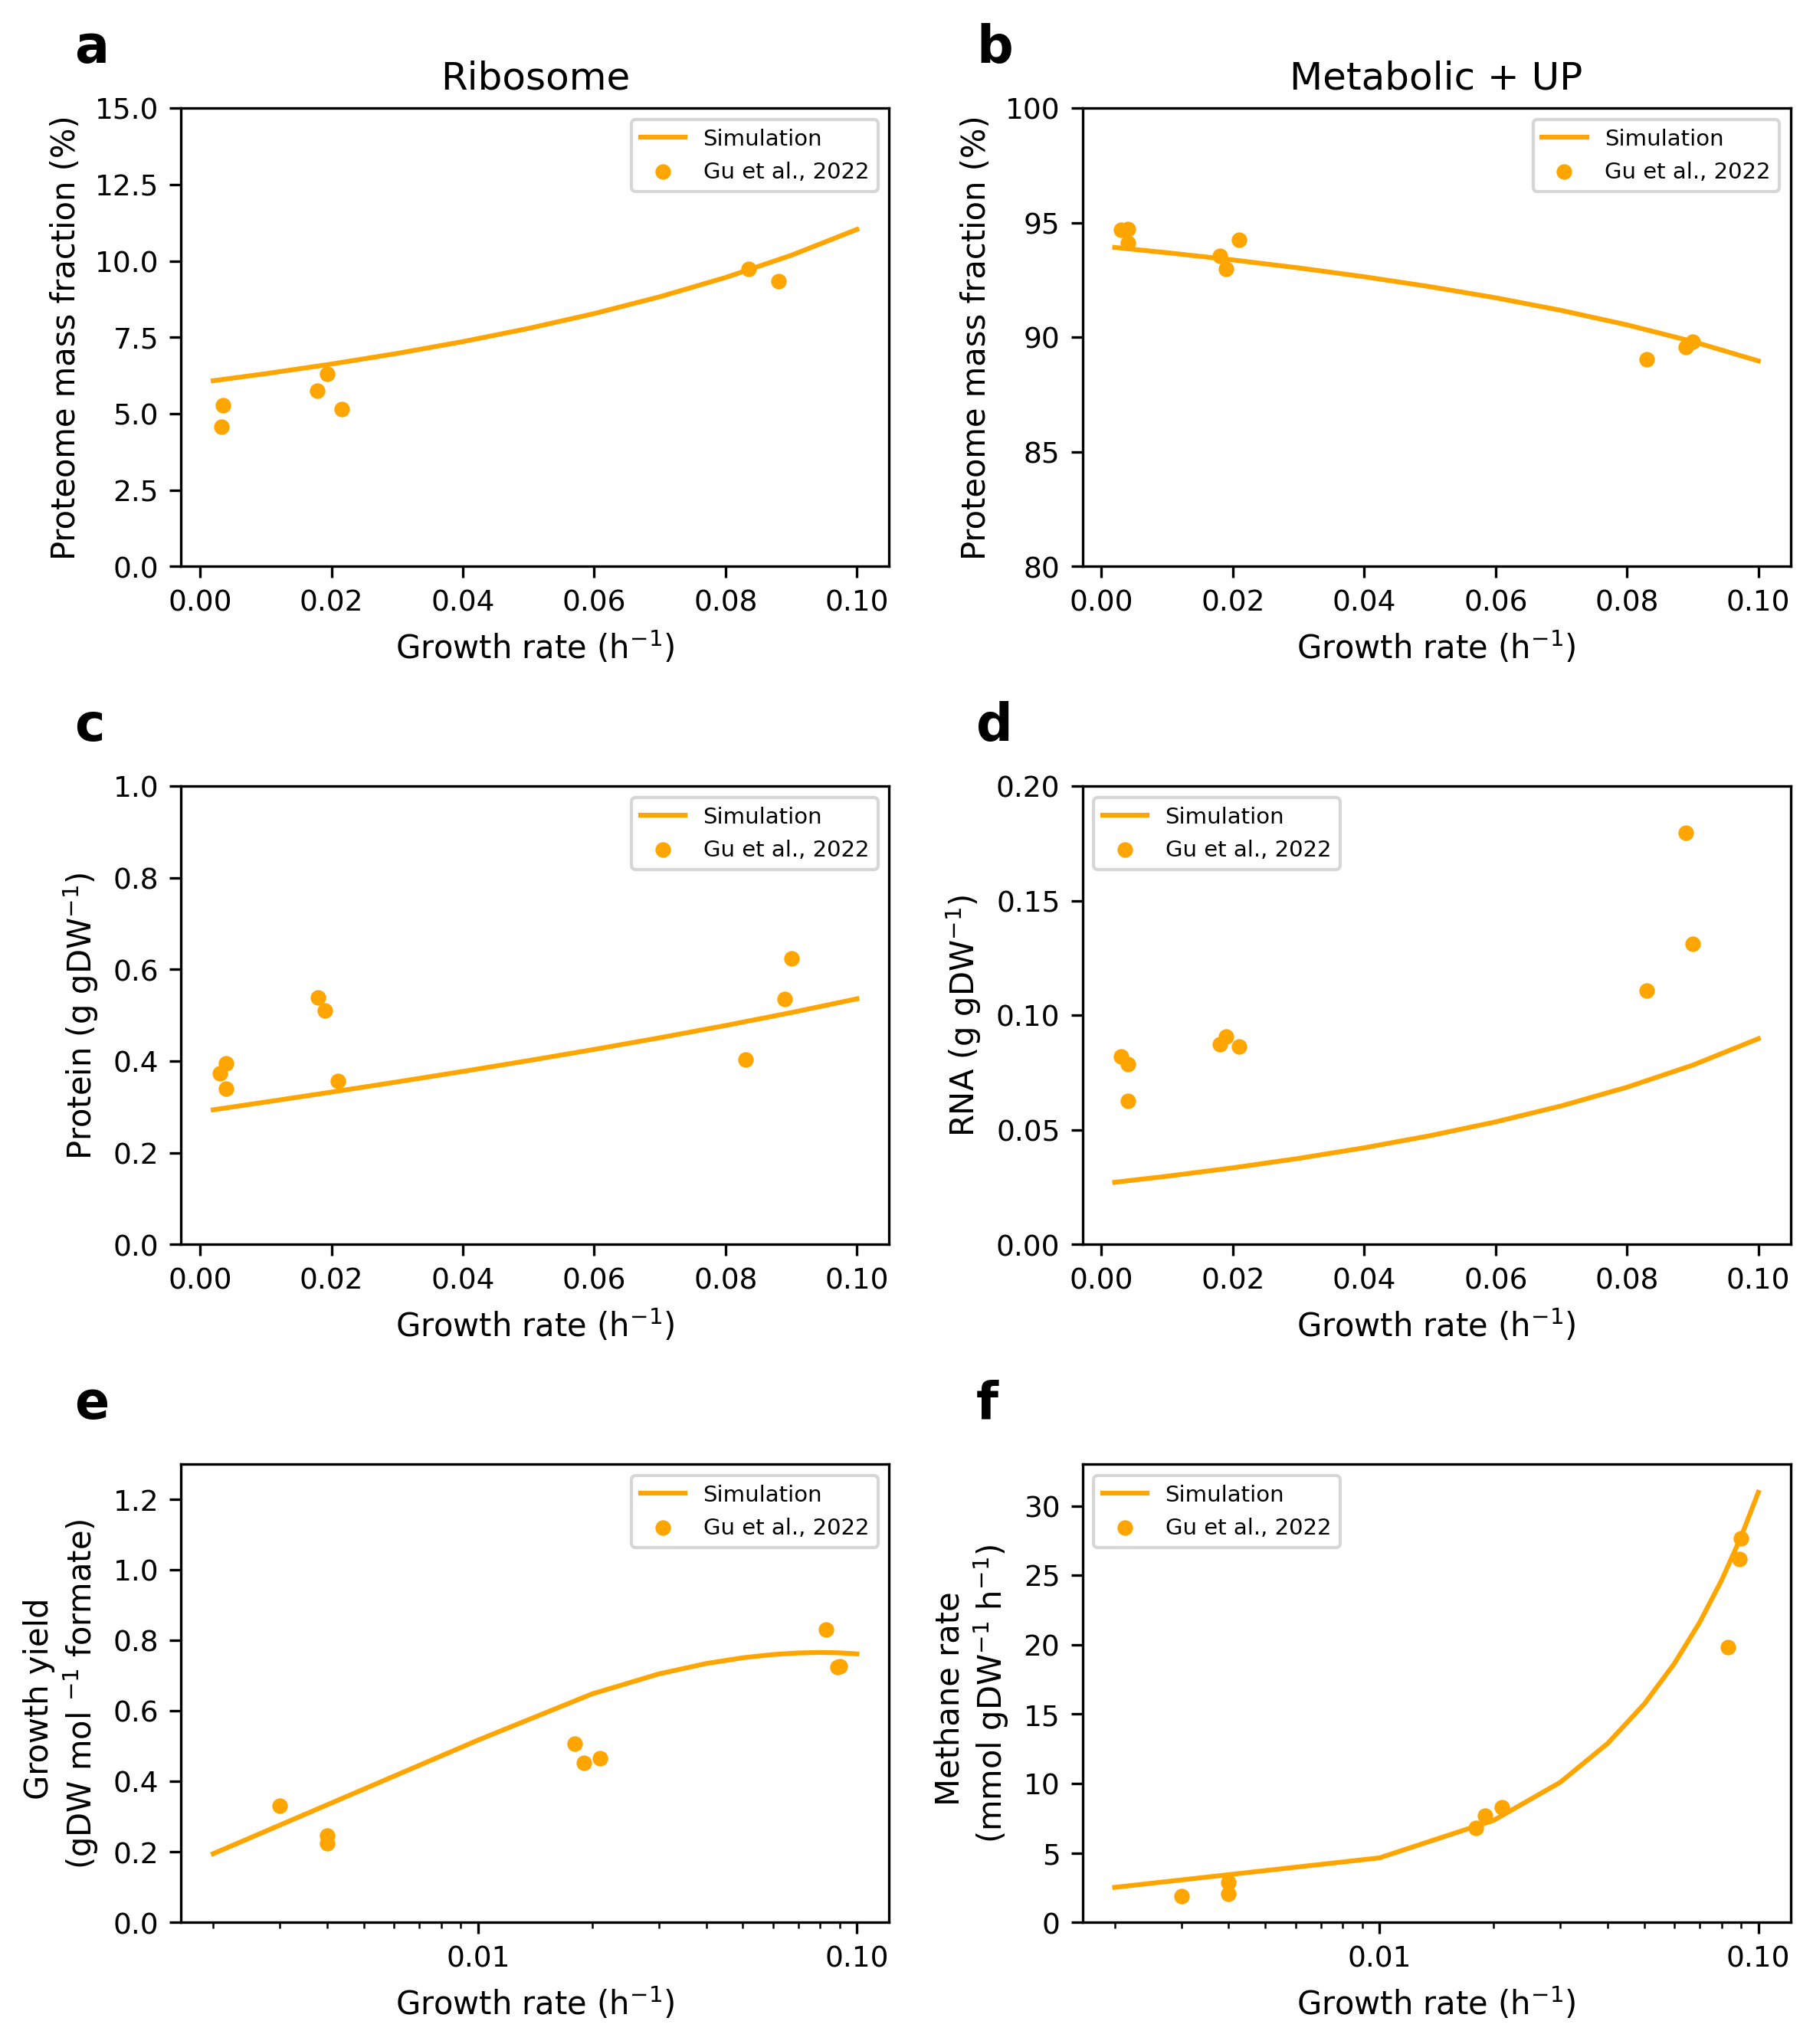

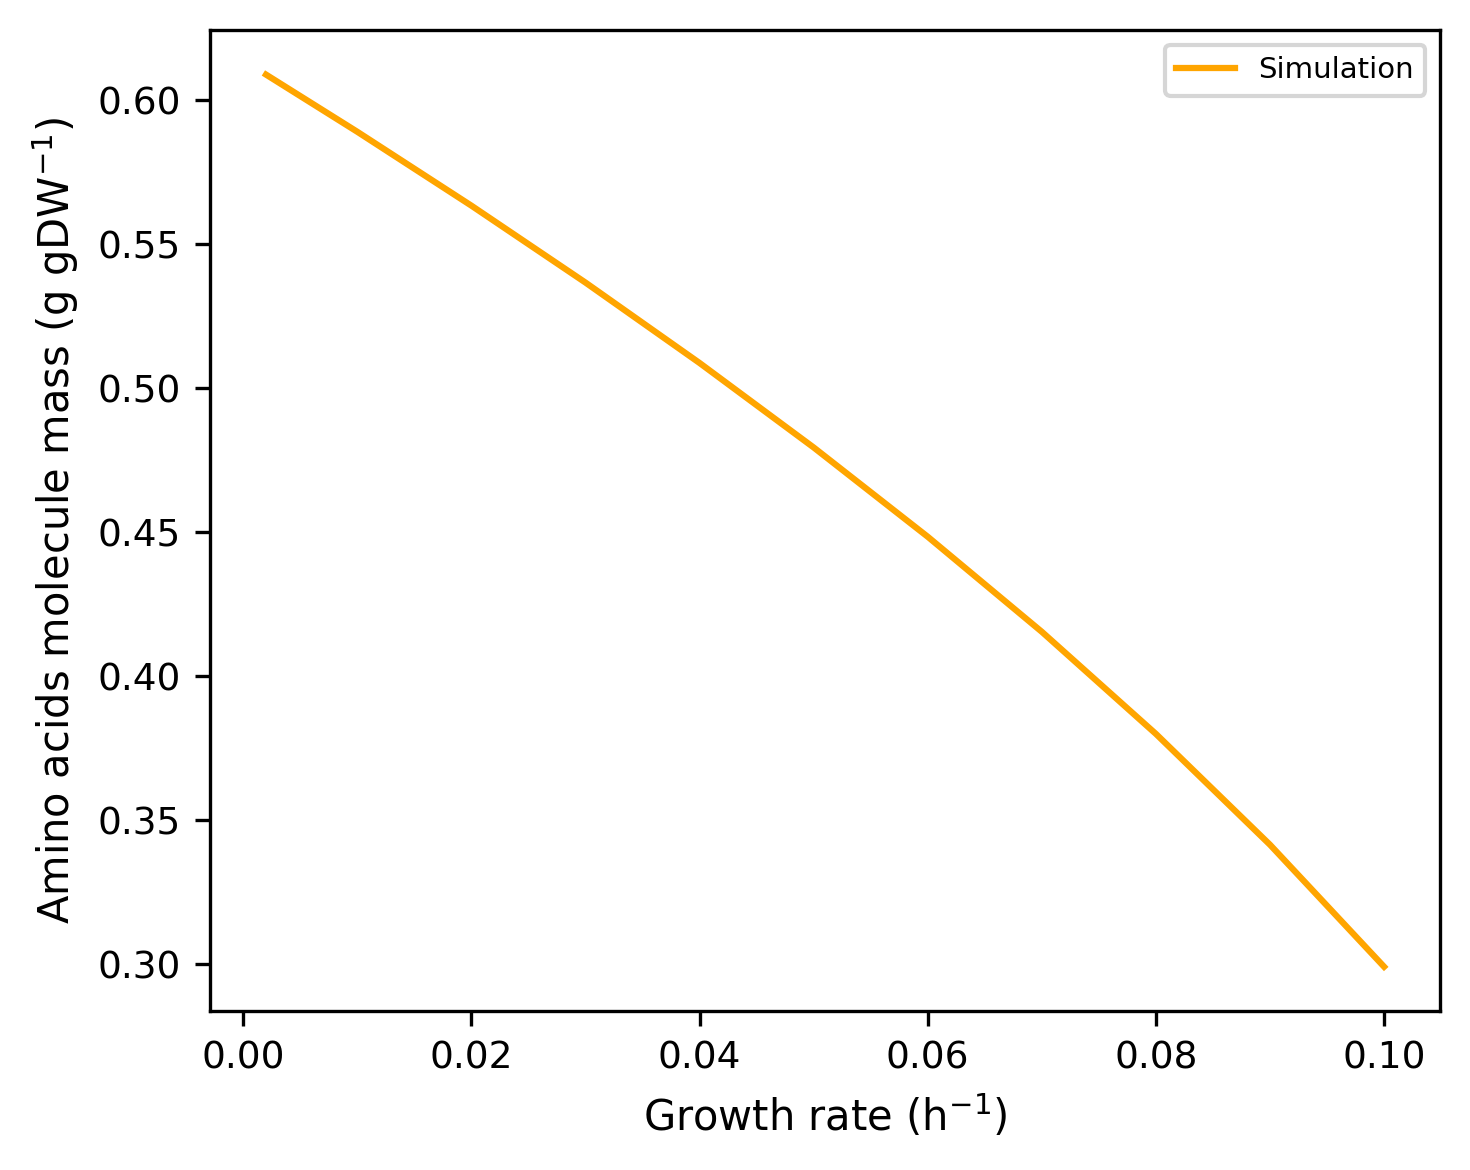

In [2]:
from simulation import Simulation
from extract_fluxes import Fluxes
import matplotlib.pyplot as plt
from cobra import*
import  numpy as np
import pandas as pd
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
def limitation_simulation():
    total_protein_mass=0.6
    up_phosphate_ratio=0.44*total_protein_mass
    methane_id,formate_id = "R944","R895"
    # closed import H2 ,CO2 , CO ,Aceteta
    closed_reactions = ["R946", "R913", "R1165", "R983"]
    sim = Simulation()
    # objective is formate 
    sim.set_parameter(model_file='pcMMP.xml', objective="R871", GAM=70, NGAM=1, excel_file='pcMMP.xlsx',aa_acids_molecule=True)
    reaction_id_V_aa_molecule="R4802"
    reaction_id_dil_V_aa_molecule="R4803"
    sim.model=add_new_reactions(sim.model,reaction_id_V_aa_molecule,reaction_id_dil_V_aa_molecule)
    sim.close_reactions(closed_reactions)
    results = {
        "mu_list": [], "methane_list": [], "formate_list": [], "rna_list": [],
         "glycogen_list": [], "metabolic_up_list": [], "methanogenesis_list": [],
        "ribosome_list": [], "total_proteins": [], "atp_list": [],"AA_molecule_mass":[]
    }
    mus=[0.002, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,0.1]
    for i, mu in enumerate(mus, start=1):
        y = -183.67*mu + 40.367
        sim.kcat_ribo = y
        constraint_aa_molecule_mass=add_constraint_aa_molecule(reaction_id_V_aa_molecule,mu)
        
        sim.set_constraint = [constraint_aa_molecule_mass,"total_protein + RNA + AA_molecule_mass = 0.93",f"UP >= {up_phosphate_ratio}"]
       
        sim.file_path = f"output/lp_file_phosphate_limited_aa_molecule_{i}.lp"
        sim.output_file = f"output/output_phosphate_limited_aa_molecule_{i}.lp"
        if sim.check_mu_optimal(mu):
            fluxes = Fluxes(sim.model, f'output/output_phosphate_limited_aa_molecule_{i}.lp')
            results["mu_list"].append(mu)
            results["methane_list"].append(fluxes.extract_reaction_flux(methane_id))
            results["formate_list"].append(fluxes.extract_reaction_flux(formate_id))
            results["rna_list"].append(fluxes.extract_reaction_flux("RNA"))
            results["glycogen_list"].append(fluxes.extract_reaction_flux("Glycogen"))
            total_protein = fluxes.extract_reaction_flux("total_protein")
            up = fluxes.extract_reaction_flux("UP")
            results["metabolic_up_list"].append(((up + fluxes.extract_reaction_flux("metaboicMass")) / total_protein)*100)
            results["methanogenesis_list"].append((fluxes.extract_reaction_flux("Methanogenesis_mass") / total_protein)*100)
            results["ribosome_list"].append((fluxes.extract_reaction_flux("ribosome_mass") / total_protein)*100)
            results["total_proteins"].append(total_protein)
            results["atp_list"].append((fluxes.extract_reaction_flux("ATP_Synthase") / total_protein)*100)
            results["AA_molecule_mass"].append(fluxes.extract_reaction_flux("AA_molecule_mass"))
  
            
        else:
            print(f"mu={mu} is not optimal")

    return results

def add_new_reactions(model,reaction_id_V_aa_molecule,reaction_id_dil_V_aa_molecule):
    V_aa_molecule=Reaction(reaction_id_V_aa_molecule)
    model.add_reactions([V_aa_molecule])
    V_aa_molecule.reaction="0.0286566875021862 L-Methionine[c0] + 0.0553177214928744 L-Arginine[c0] + 0.0959550569859981 L-Alanine[c0] + 0.0473283805249331 L-Threonine[c0] + 0.0450322578330521 L-Aspartate[c0] + 0.114328523135678 Glycine[c0] + 0.0640044200361819 L-Lysine[c0] + 0.0402404470981404 L-Serine[c0] + 0.0491267109925977 L-Glutamate[c0] + 0.0491267109925977 L-Glutamine[c0] + 0.0170742732906219 L-Cysteine[c0] + 0.0841739743462104 L-Leucine[c0] + 0.0270601646929878 L-Tyrosine[c0] + 0.0450322578330521 L-Asparagine[c0] + 0.0105841389943521 L-Tryptophan[c0] + 0.0413369353758062 L-Proline[c0] + 0.0542189909078923 L-Isoleucine[c0] + 0.0346481326513131 L-Phenylalanine[c0] + 0.0177734247118411 L-Histidine[c0] + 0.0789807906016828 L-Valine[c0] => AA"
    V_dil_aa_molecule=Reaction(reaction_id_dil_V_aa_molecule)
    model.add_reactions([V_dil_aa_molecule])
    V_dil_aa_molecule.reaction="AA -->"
    
    return model

def add_constraint_aa_molecule(reaction_id_V_aa_molecule,mu):
    MW=(126.4025198/1000)
    M=(1/mu)  
    value=M*MW
    return f"{value} {reaction_id_V_aa_molecule} - AA_molecule_mass = 0"


def calculate_growth_yield(mu_list, formate_list):
    growth_yield=[]
    for i in range(len(formate_list)):
        value = (mu_list[i]/formate_list[i])*1000
        growth_yield.append(value)
    return growth_yield
def plot(results_phosphate):
    plt.rcParams.update({
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize":9,
        "ytick.labelsize": 9,
        "legend.fontsize": 7
    })

    mu_list = results_phosphate['mu_list']

     # exp_data : experiment data from Gu et al., 2022

    growth_rate_ribosome_phosphate= [0.003272973, 0.003487615, 0.021544347, 0.017806336, 0.019380114, 0.083529305, 0.088069874]
    ribsome_proteome_phosphate=[4.577735363, 5.268714659, 5.153551077, 5.758158235, 6.305182504, 9.73128644, 9.328215001]
    growth_rate_metabolic_up_phosphate=[0.004,0.003,0.004,0.019,0.018,0.021,0.089,0.083,0.090]
    metabolic_up_proteome_phosphate=[94.72140762,94.69831643,94.10985305,92.98337479,93.54020768,94.2591956,89.57755165,89.03666427,89.80582524]


    growth_rate_protein_phosphate= [0.004,0.003,0.004,0.019,0.018,0.021,0.089,0.083,0.090]
    protein_phosphate=[0.340122082,0.373015028,0.394486759,0.510297316,0.539535463,0.357482229,0.534967025,0.403166849,0.623595176]
   
    growth_rate_rna_phosphate= [0.004,0.003,0.004,0.019,0.018,0.021,0.089,0.083,0.090]
    rna_phosphate=[0.062555704,0.08202801,0.078822118,0.090647634,0.087375565,0.086344534,0.17950974,0.110794618,0.131342481]
    
    growth_rate_methane_phosphate=[0.004,0.003,0.004,0.019,0.018,0.021,0.089,0.083,0.090]
    methane_phosphate= [2.083885863,1.870735601,2.887474099,7.68678161,6.80696414,8.320792899,26.18546801,19.84223989,27.64679579]

    growth_rate_growth_yeild_phosphate=[0.004,0.003,0.004,0.019,0.018,0.021,0.089,0.083,0.09]
    growth_yeild_phosphate= [0.246716582,0.330948668,0.225061064,0.452231567,0.506059412,0.464795751,0.724912652,0.830659816,0.727062121]
    
  

    fig, axes = plt.subplots(3, 2, figsize=(8, 9), dpi=300)  
    subplot_labels = ["a", "b", "c", "d", "e", "f"]

    # --- Ribosome ---
    axes[0, 0].plot(mu_list, results_phosphate['ribosome_list'], label="Simulation", color='orange')
    axes[0, 0].scatter(growth_rate_ribosome_phosphate, ribsome_proteome_phosphate,  s=15, label="Gu et al., 2022",color='orange')
    axes[0, 0].set_title("Ribosome")
    axes[0, 0].set_ylabel("Proteome mass fraction (%)")
    axes[0, 0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 15)
    axes[0, 0].text(-0.15, 1.1, subplot_labels[0], transform=axes[0, 0].transAxes, fontsize=16, fontweight='bold')

    # --- Metabolic + UP ---
    axes[0, 1].plot(mu_list, results_phosphate['metabolic_up_list'], label="Simulation", color='orange')
    axes[0, 1].scatter(growth_rate_metabolic_up_phosphate, metabolic_up_proteome_phosphate,  s=15, label="Gu et al., 2022",color='orange')
    axes[0, 1].set_title("Metabolic + UP")
    axes[0, 1].set_ylabel("Proteome mass fraction (%)")
    axes[0, 1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0, 1].legend()
    axes[0, 1].set_ylim(80, 100)
    axes[0, 1].text(-0.15, 1.1, subplot_labels[1], transform=axes[0, 1].transAxes, fontsize=16, fontweight='bold')

    # --- Protein ---
    axes[1, 0].plot(mu_list, results_phosphate['total_proteins'], label="Simulation",color='orange')
    axes[1, 0].scatter(growth_rate_protein_phosphate, protein_phosphate,  s=15, label="Gu et al., 2022",color='orange')
    axes[1, 0].set_ylabel("Protein (g gDW$^{-1}$)")
    axes[1, 0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1, 0].legend()
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].text(-0.15, 1.1, subplot_labels[2], transform=axes[1, 0].transAxes, fontsize=16, fontweight='bold')

    # --- RNA ---
    axes[1, 1].plot(mu_list, results_phosphate['rna_list'], label="Simulation", color='orange')
    axes[1, 1].scatter(growth_rate_rna_phosphate, rna_phosphate,  s=15, label="Gu et al., 2022",color='orange')
    axes[1, 1].set_ylabel("RNA (g gDW$^{-1}$)")
    axes[1, 1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1, 1].legend()
    axes[1, 1].set_ylim(0,0.2)
    axes[1, 1].text(-0.15, 1.1, subplot_labels[3], transform=axes[1, 1].transAxes, fontsize=16, fontweight='bold')

    # --- Growth yield  ---
    growth_yield_phosphate=calculate_growth_yield(mu_list, results_phosphate["formate_list"])
  
    axes[2, 0].plot(mu_list, growth_yield_phosphate, label="Simulation", color='orange')
    axes[2, 0].scatter(growth_rate_growth_yeild_phosphate, growth_yeild_phosphate,  s=15, label="Gu et al., 2022",color='orange')
    axes[2, 0].set_ylabel("Growth yield \n(gDW mol $^{-1}$ formate)")
    axes[2, 0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[2, 0].legend()
    axes[2, 0].set_xscale('log')
    axes[2, 0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[2, 0].set_ylim(0,1.30)
    axes[2, 0].text(-0.15, 1.1, subplot_labels[4], transform=axes[2, 0].transAxes, fontsize=16, fontweight='bold')

    # --- methane  ----
    axes[2, 1].plot(mu_list, results_phosphate['methane_list'], label="Simulation", color='orange')
    axes[2, 1].scatter(growth_rate_methane_phosphate, methane_phosphate,  s=15, label="Gu et al., 2022",color='orange')
    axes[2, 1].set_ylabel("Methane rate \n(mmol gDW$^{-1}$ h$^{-1}$)")
    axes[2, 1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[2, 1].legend()
    axes[2, 1].set_ylim(0, 33)
    axes[2, 1].set_xscale('log')
    axes[2, 1].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[2, 1].text(-0.15, 1.1, subplot_labels[5], transform=axes[2, 1].transAxes, fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.savefig("Figures/phosphate_limited_amino_acids.png", dpi=300)
    plt.show()
 

    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
    ax.plot(results_phosphate["mu_list"], results_phosphate["AA_molecule_mass"], label="Simulation", color="orange")

    ax.set_xlabel("Growth rate (h$^{-1}$)")
    ax.set_ylabel("Amino acids molecule mass (g gDW$^{-1}$)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("Figures/phosphate_limited_aa_mass.png", dpi=300)
    plt.show()
    
if __name__ == "__main__": 
    results_phosphate = limitation_simulation()
    plot(results_phosphate)